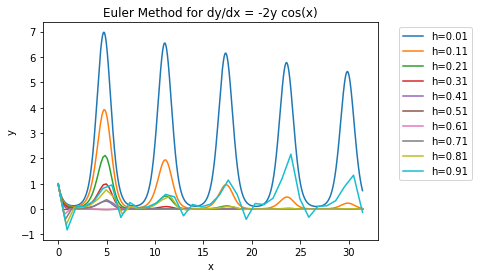

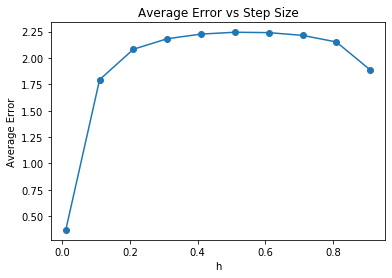

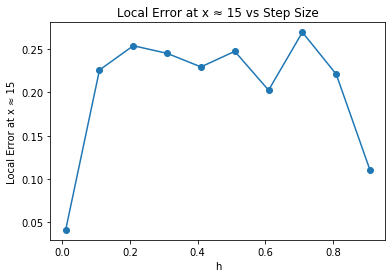

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Function dy/dx = -2y*cos(x)
def f(x, y):
    return -2 * y * np.cos(x)

# Exact real solution
def real_solution(x):
    return np.exp(-2 * np.sin(x))

# Euler method 
def euler_method(h):
    x_start, x_end = 0, 10 * np.pi
    num_steps = int((x_end - x_start) / h)

    x_values = np.linspace(x_start, x_end, num_steps + 1)
    y_values = np.zeros(num_steps + 1)

    y_values[0] = 1

    for i in range(num_steps):
        y_values[i + 1] = y_values[i] + h * f(x_values[i], y_values[i])

    return x_values, y_values


# Step sizes
h_values = np.arange(0.01, 1.01, 0.1)

avg_errors = []
local_errors_15 = []

plt.figure()


# Plot 1: Euler solutions
for h in h_values:
    x_vals, y_vals = euler_method(h)

    plt.plot(x_vals, y_vals, label=f"h={h:.2f}")

    # Exact real solution at same points
    y_real = real_solution(x_vals)

    # Average error
    error = np.abs(y_vals - y_real)
    avg_errors.append(np.mean(error))

    # Value near x = 15 - ChatGPT used to confirm implementation
    idx = np.argmin(np.abs(x_vals - 15))
    local_error_15 = abs(y_vals[idx] - real_solution(x_vals[idx]))
    local_errors_15.append(local_error_15)

plt.xlabel('x')
plt.ylabel('y')
plt.title("Euler Method for dy/dx = -2y cos(x)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# Plot 2: Avg error vs h
plt.figure()
plt.plot(h_values, avg_errors, marker='o')
plt.xlabel('h')
plt.ylabel('Average Error')
plt.title("Average Error vs Step Size")
plt.show()

# Plot 3: Local error at x ≈ 15
plt.figure()
plt.plot(h_values, local_errors_15, marker='o')
plt.xlabel('h')
plt.ylabel('Local Error at x = 15')
plt.title("Local Error at x = 15 vs Step Size")
plt.show()